In [30]:
from qitf_model import *
import numpy as np
from entropy import *

exact_model = QITFModel(hx=0.809,J=1)
analog_model = analog_QITF(exact_model, delta=[(rand.normalvariate(0, 0.1)) for _ in range(10)],eta=0)
# analog_model = analog_QITF(exact_model, delta=0,eta=0.001)
import pickle

with open('./data/analog_model[d].pkl', 'wb') as f:
    pickle.dump(analog_model, f)

# with open('./data/analog_model[i].pkl', 'rb') as f:
#     analog_model = pickle.load(f)

In [ ]:
initial_state = Statevector.from_label('0'*N).data  # Typical case state

fro_curve=[]
spec_curve=[]
V_fro = np.linalg.norm(analog_model.perm, 'fro')/sqrt(d)
V_spec = np.linalg.norm(analog_model.perm, 2)

estimate_fro = 0
U_int = exact_model.get_evolution_segment(segment_time=0.01)
state=initial_state
for t in np.linspace(0,10,11):
    fro_curve.append(estimate_fro)
    for i in range(10):
        estimate_fro += 0.01 * sqrt(abs(state.conj().T@(analog_model.perm.conj().T@analog_model.perm)@state))
        state = U_int @ state
for t in range(50):
    fro_curve.append(fro_curve[-1]+0.1*V_fro)

estimate_spec = 0
initial_state = Statevector.from_label('+'*N).data  # Atypical case state
state=initial_state
for t in np.linspace(0,60,61):
    spec_curve.append(estimate_spec)
    for i in range(10):
        estimate_spec += 0.01 * np.linalg.norm(analog_model.perm@state)
        state = U_int @ state

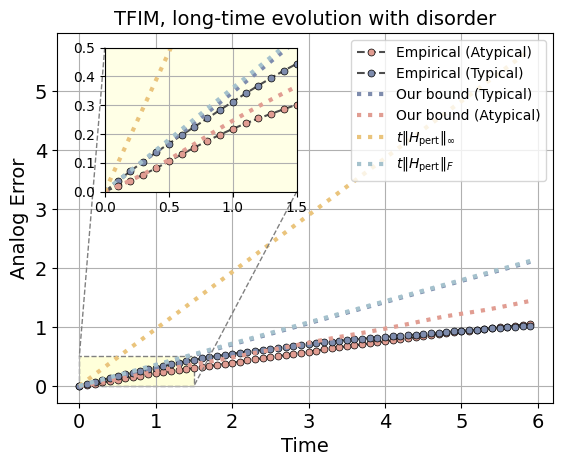

In [ ]:
initial_state=Statevector.from_label('+'*N).data
    # analog_model.plot_one_segment(initial_state, mfc='#66C999', label='Separable State')
analog_model.plot_long_time(initial_state, mfc="#E19D92", label='Empirical (Atypical)')

# initial_state = haar_random_state(N)  # Generate a random state
initial_state = Statevector.from_label('0'*N).data  # Typical case state
analog_model.plot_long_time(initial_state, mfc='#7E8CAD', label='Empirical (Typical)')

linear_curve=[]
for t in time:
    linear_curve.append(t*V_fro)
worst_curve =[]
for t in time:
    worst_curve.append(t*V_spec)

plt.plot(time[:-1], fro_curve[:-1], color="#7E8CAD", linestyle='dotted', label='Our bound (Typical)',linewidth=3)
plt.plot(time[:-1], spec_curve[:-1], color="#E19D92", linestyle='dotted', label='Our bound (Atypical)',linewidth=3)
plt.plot(time[:-1], worst_curve[:-1], color="#EAC47C", linestyle='dotted', label=r'$t\|H_{\text{pert}}\|_{\infty}$',linewidth=3)
plt.plot(time[:-1], linear_curve[:-1], color="#A5C2CD", linestyle='dotted', label=r'$t\|H_{\text{pert}}\|_{F}$',linewidth=3)

plt.xlabel('Time',fontsize=14)
plt.ylabel('Analog Error',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.ylim( top=0.3)
plt.legend(loc=1)
plt.title('TFIM, long-time evolution with disorder',fontsize=14)
plt.grid()
ax1=plt.gca()

from mpl_toolkits.axes_grid1.inset_locator import mark_inset, BboxConnector

ax2=plt.axes([0.2,0.55,0.3,0.3])
ax2.set_xlim(0,1.5)
ax2.set_ylim(0,0.5)
ax2.set_facecolor("#ffffe6")

analog_model.plot_long_time(initial_state, mfc='#7E8CAD',label='Empirical (Typical)')
plt.plot(time[:-1], fro_curve[:-1], color='#7E8CAD', linestyle='dotted', linewidth=3)
plt.plot(time[:-1], linear_curve[:-1], color="#A5C2CD", linestyle='dotted', linewidth=3)
initial_state = Statevector.from_label('+'*N).data  # Atypical case state
analog_model.plot_long_time(initial_state, mfc="#E19D92", label='Atypical Case State')
plt.plot(time[:-1], spec_curve[:-1], color="#E19D92", linestyle='dotted', label='Our bound (Atypical)',linewidth=3)
plt.plot(time[:-1], worst_curve[:-1], color="#EAC47C", linestyle='dotted', label=r'$t\|H_{\text{pert}}\|_{\infty}$',linewidth=3)


plt.grid()
# plt.tight_layout()
mark_inset(ax1, ax2, loc1=2, loc2=4, fc="#ffffda", ec="0.5",linestyle='dashed')
plt.savefig('./Figures/long-time[d,c=1].pdf', bbox_inches='tight',dpi=600)
plt.show()

C:\Users\minidas\AppData\Local\Temp\ipykernel_12184\2881770365.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), fontsize=14)
C:\Users\minidas\AppData\Local\Temp\ipykernel_12184\2881770365.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(ax1.get_yticklabels(), fontsize=14)
C:\Users\minidas\AppData\Local\Temp\ipykernel_12184\2881770365.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels(ax2.get_yticklabels(), fontsize=14)


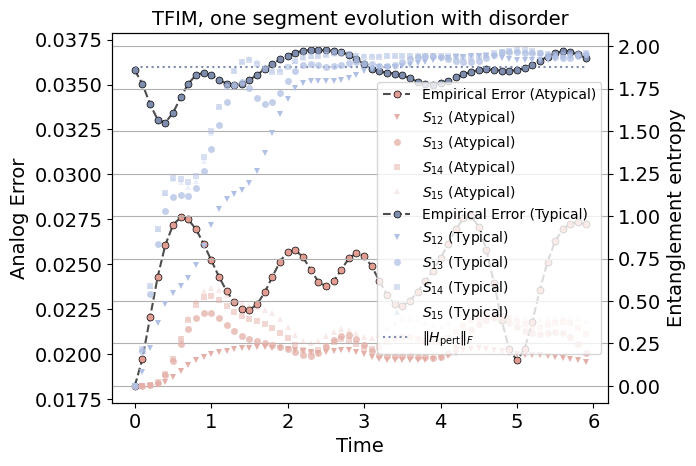

In [ ]:
from entropy import entropy_data
import matplotlib.pyplot as plt

initial_state=Statevector.from_label('+'*N).data
fig, ax1 =plt.subplots()
state_distance = []
exact_state = initial_state
analog_state = initial_state
for i in range(num_steps):    
    analog_state = analog_model.U0 @ exact_state
    exact_state = analog_model.exact_model.U0 @ exact_state
    state_distance.append(np.linalg.norm(exact_state - analog_state))
p11=ax1.plot(time[:-1], state_distance, color='0.3', marker='o', markersize=5, mfc='#E19D92', mec='k', linestyle='dashed', markeredgewidth=0.5,label='Empirical Error (Atypical)')
ax2=ax1.twinx()
entropy_list=entropy_data(initial_state, analog_model, k=2)
p12=ax2.plot(time[:-1], entropy_list[:-1], label=r'$S_{12}$ (Atypical)',marker='v', markersize=5, mfc="#E4AFA7", linewidth=0,markeredgewidth=0,mec='k')
entropy_list=entropy_data(initial_state, analog_model, k=[1,3,4,5,6,7,8,9])
p14=ax2.plot(time[:-1], entropy_list[:-1],label=r'$S_{13}$ (Atypical)', marker='o', markersize=5, mfc='#E4AFA7', linewidth=0,markeredgewidth=0,alpha=0.75,mec='k')
entropy_list=entropy_data(initial_state, analog_model, k=[1,2,4,5,6,7,8,9])
p15=ax2.plot(time[:-1], entropy_list[:-1],label=r'$S_{14}$ (Atypical)', marker='s', markersize=5, mfc='#E4AFA7', linewidth=0,markeredgewidth=0,alpha=0.5,mec='k')
entropy_list=entropy_data(initial_state, analog_model, k=[1,2,3,5,6,7,8,9])
p16=ax2.plot(time[:-1], entropy_list[:-1],label=r'$S_{15}$ (Atypical)', marker='^', markersize=5, mfc='#E4AFA7', linewidth=0,markeredgewidth=0,alpha=0.25,mec='k')

# initial_state = haar_random_state(N)  # Generate a random state
initial_state = Statevector.from_label('0'*N).data  # Typical case state
state_distance = []
exact_state = initial_state
analog_state = initial_state
for i in range(num_steps):    
    analog_state = analog_model.U0 @ exact_state
    exact_state = analog_model.exact_model.U0 @ exact_state
    state_distance.append(np.linalg.norm(exact_state - analog_state))
p21=ax1.plot(time[:-1], state_distance, color='0.3', marker='o', markersize=5, mfc='#7E8CAD', mec='k', linestyle='dashed', markeredgewidth=0.5,label='Empirical Error (Typical)')

entropy_list=entropy_data(initial_state, analog_model, k=2)
p22=ax2.plot(time[:-1], entropy_list[:-1],label=r'$S_{12}$ (Typical)',marker='v', markersize=5, mfc="#B0C0E4", linewidth=0,markeredgewidth=0,mec='k')
entropy_list=entropy_data(initial_state, analog_model, k=[1,3,4,5,6,7,8,9])
p24=ax2.plot(time[:-1], entropy_list[:-1],label=r'$S_{13}$ (Typical)', marker='o', markersize=5, mfc='#B0C0E4', linewidth=0,markeredgewidth=0,alpha=0.75,mec='k')
entropy_list=entropy_data(initial_state, analog_model, k=[1,2,4,5,6,7,8,9])
p25=ax2.plot(time[:-1], entropy_list[:-1],label=r'$S_{14}$ (Typical)', marker='s', markersize=5, mfc='#B0C0E4', linewidth=0,markeredgewidth=0,alpha=0.5,mec='k')
entropy_list=entropy_data(initial_state, analog_model, k=[1,2,3,5,6,7,8,9])
p26=ax2.plot(time[:-1], entropy_list[:-1],label=r'$S_{15}$ (Typical)', marker='^', markersize=5, mfc='#B0C0E4', linewidth=0,markeredgewidth=0,alpha=0.25,mec='k')

p13=ax1.plot(time[:-1], [V_fro*time_step]*num_steps, color="#7E8CAD", linestyle='dotted', label=r'$\|H_{\text{pert}}\|_{F}$')
# plt.plot(time[:-1], [V_spec*time_step]*num_steps, color='#A4E048', linestyle='dashed', label=r'$\delta t\lambda\|V\|_{\infty}$')
ax1.set_xlabel('Time',fontsize=14)
ax1.set_ylabel('Analog Error',fontsize=14)
ax2.set_ylabel('Entanglement entropy',fontsize=14)
ax1.set_xticklabels(ax1.get_xticklabels(), fontsize=14)
ax1.set_yticklabels(ax1.get_yticklabels(), fontsize=14)
ax2.set_yticklabels(ax2.get_yticklabels(), fontsize=14)
lns=p11+p12+p14+p15+p16+p21+p22+p24+p25+p26+p13
labs=[l.get_label() for l in lns]
plt.title('TFIM, one segment evolution with disorder',fontsize=14)
plt.legend(lns,labs,loc=5)
plt.grid()
plt.savefig('./Figures/one_segment[d].pdf', bbox_inches='tight',dpi=600)
plt.show()